In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
dataset_path = "spotify_top_1000_tracks.csv"
df = pd.read_csv(dataset_path, encoding="utf-8")

# Ensure 'year' column exists
if 'release_date' in df.columns:
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df['year'] = df['release_date'].dt.year
elif 'release_year' in df.columns:
    df['year'] = df['release_year']

# Student personalization
student_name = "Jhonren Traballo"
student_id = "4766"
id_num = int(student_id[-3:])
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"


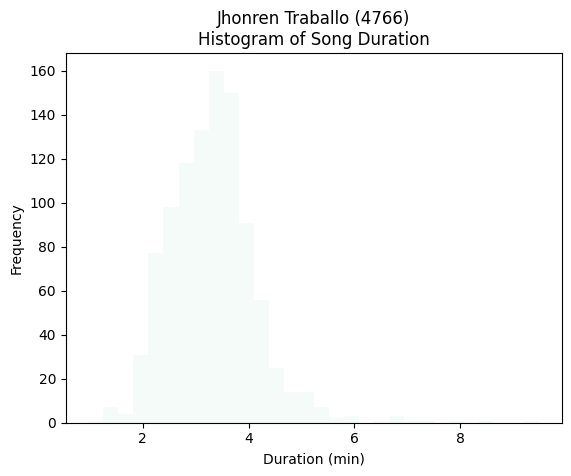

In [31]:
# Code Snippet 1 
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.show()


C:\Users\Jhonren\AppData\Local\Temp\ipykernel_24320\2487914725.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


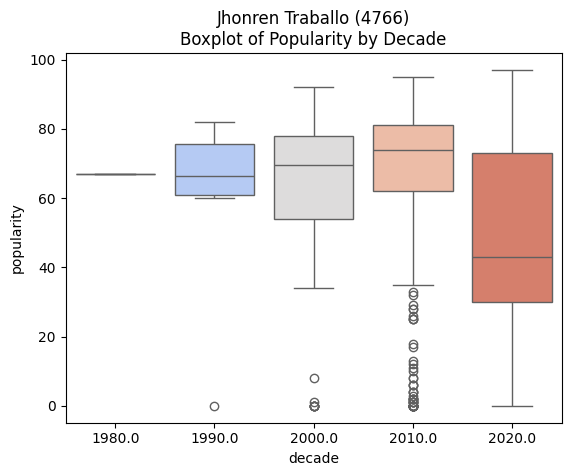

In [32]:
# Code Snippet 2 
df['decade'] = (df['year'] // 10) * 10
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.show()


C:\Users\Jhonren\AppData\Local\Temp\ipykernel_24320\2963902937.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df, order=df['artist'].value_counts().head(10).index, palette='viridis')


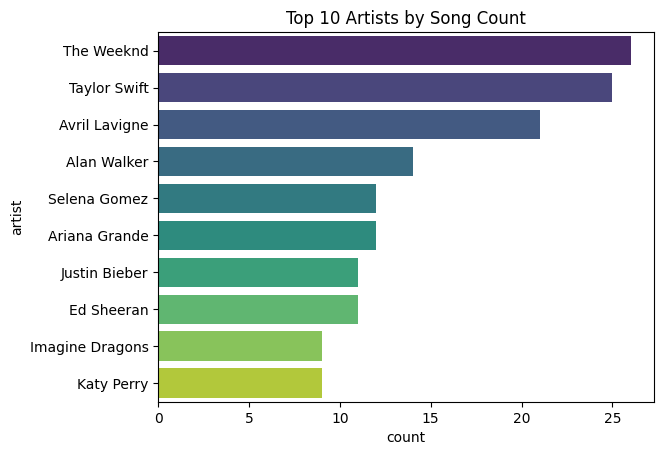

In [33]:
# Code Snippet 3
sns.countplot(y='artist', data=df, order=df['artist'].value_counts().head(10).index, palette='viridis')
plt.title("Top 10 Artists by Song Count")
plt.show()


C:\Users\Jhonren\AppData\Local\Temp\ipykernel_24320\1814760059.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm', scale='width')
C:\Users\Jhonren\AppData\Local\Temp\ipykernel_24320\1814760059.py:2: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm', scale='width')


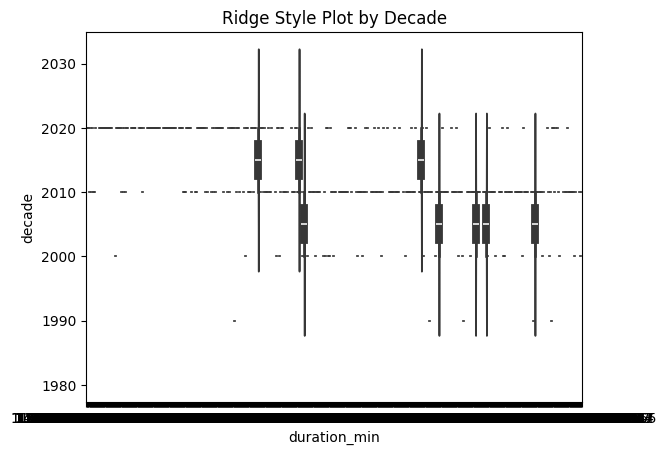

In [34]:
# Code Snippet 4
sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm', scale='width')
plt.title("Ridge Style Plot by Decade")
plt.show()


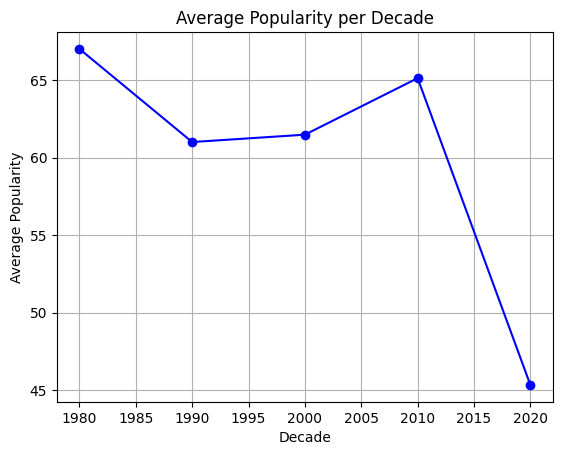

In [35]:
# Code Snippet 5
avg_pop = df.groupby('decade')['popularity'].mean()
avg_pop.plot(kind='line', color='blue', marker='o')
plt.title("Average Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True)
plt.show()


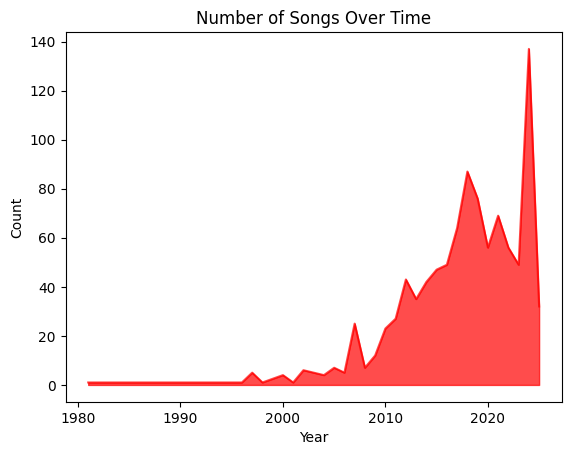

In [36]:
# Code Snippet 6
count_by_year = df['year'].value_counts().sort_index()
count_by_year.plot(kind='area', color='red', alpha=0.7)
plt.title("Number of Songs Over Time")
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


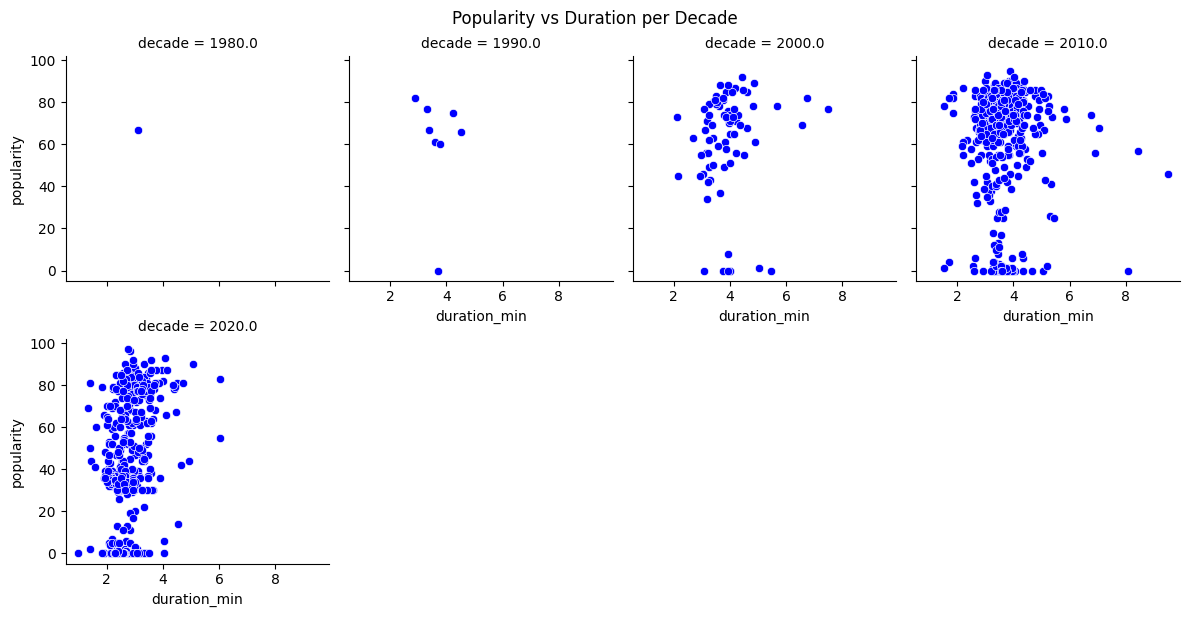

In [37]:
# Code Snippet 7
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity', color='blue')
g.fig.suptitle("Popularity vs Duration per Decade", y=1.02)
plt.show()


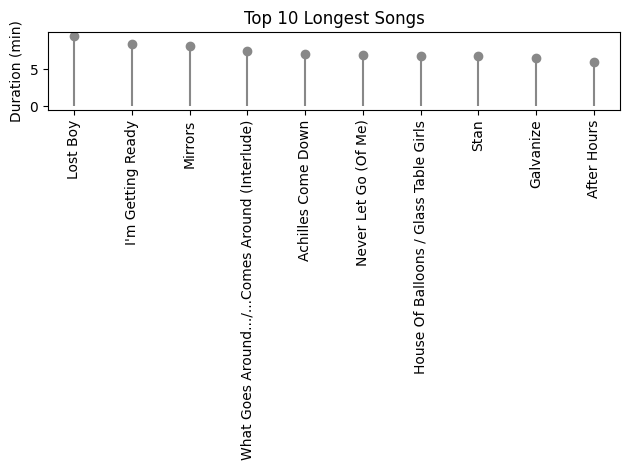

In [38]:
# Code Snippet 8
longest = df.nlargest(10, 'duration_min')
plt.stem(longest['track_name'], longest['duration_min'], linefmt='#888888', markerfmt='o', basefmt=" ")
plt.xticks(rotation=90)
plt.title("Top 10 Longest Songs")
plt.ylabel('Duration (min)')
plt.tight_layout()
plt.show()


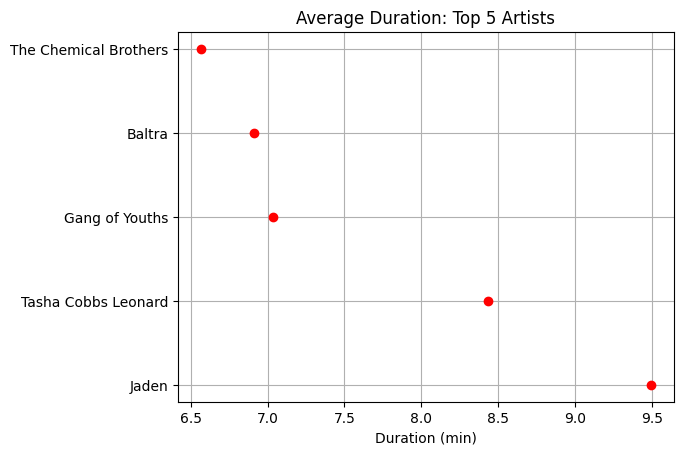

In [39]:
# Code Snippet 9
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)
plt.plot(avg_duration.values, avg_duration.index, 'o', color='red')
plt.title("Average Duration: Top 5 Artists")
plt.xlabel('Duration (min)')
plt.grid(True)
plt.show()


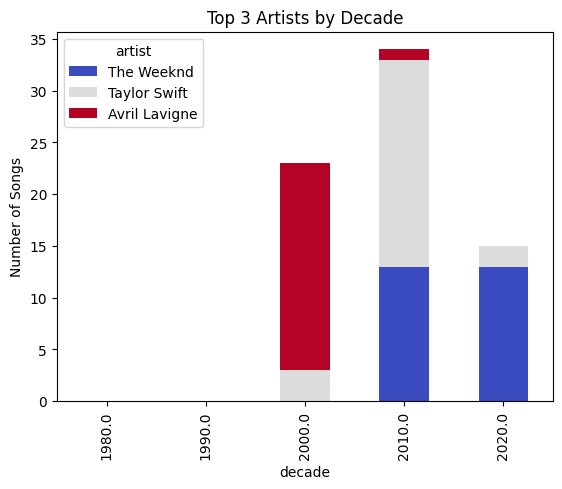

In [40]:
# Code Snippet 10
crosstab = pd.crosstab(df['decade'], df['artist'])
top3 = df['artist'].value_counts().head(3).index
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title("Top 3 Artists by Decade")
plt.ylabel('Number of Songs')
plt.show()


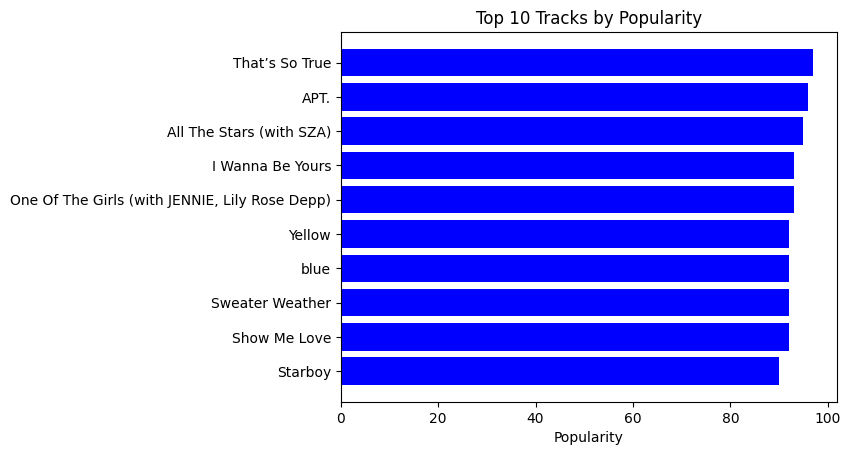

In [41]:
# Code Snippet 11
top_tracks = df.nlargest(10, 'popularity')
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color='blue')
plt.xlabel('Popularity')
plt.title("Top 10 Tracks by Popularity")
plt.gca().invert_yaxis()
plt.show()


C:\Users\Jhonren\AppData\Local\Temp\ipykernel_24320\1628533186.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', y='duration_min', palette=['#8C1515', '#888888'])
C:\Users\Jhonren\AppData\Local\Temp\ipykernel_24320\1628533186.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', y='duration_min', palette=['#8C1515', '#888888'])


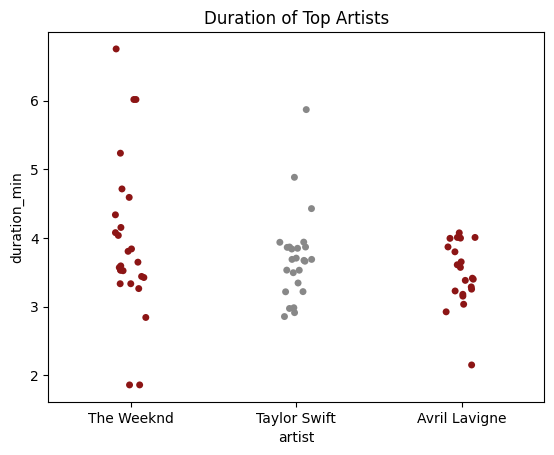

In [42]:
# Code Snippet 12
top_artists = df['artist'].value_counts().head(3).index
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', y='duration_min', palette=['#8C1515', '#888888'])
plt.title("Duration of Top Artists")
plt.show()


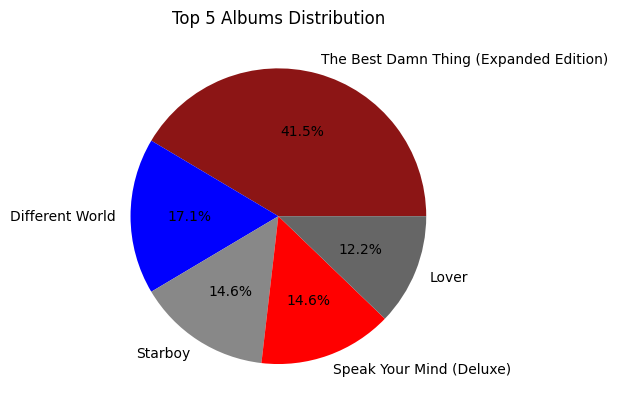

In [43]:
# Code Snippet 13
top_albums = df['album'].value_counts().head(5)
colors = ['#8C1515', 'blue', '#888888', 'red', '#666666']
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', colors=colors)
plt.title("Top 5 Albums Distribution")
plt.show()


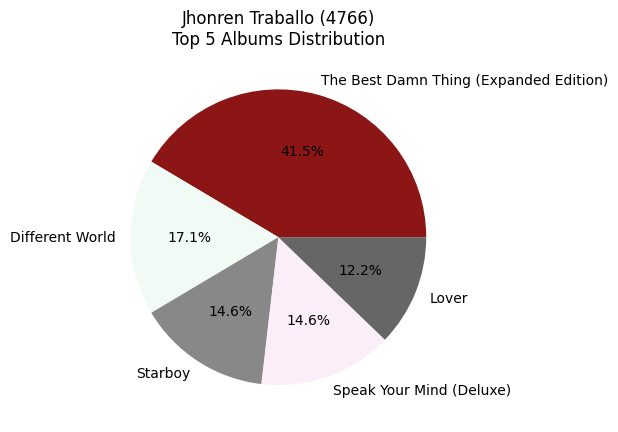

In [45]:
# Code Snippet 13 (fixed with safety check)
if 'album' in df.columns:
    top_albums = df['album'].value_counts().head(5)
    colors = ['#8C1515', color1, '#888888', color2, '#666666']
    plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', colors=colors)
    plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution")
    plt.show()
else:
    print("Column 'album' not found in dataset.")


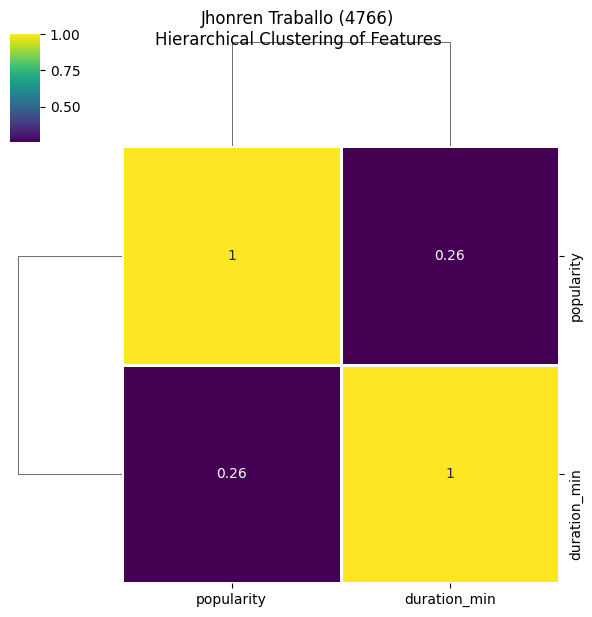

In [4]:
# Code Snippet 14 (final fixed)
import seaborn as sns
import matplotlib.pyplot as plt
import scipy 

numerical_cols = ['popularity', 'duration_min']
df_numeric = df[numerical_cols].dropna()

sns.clustermap(df_numeric.corr(), annot=True, cmap='viridis', linewidths=.75, figsize=(6, 6))
plt.suptitle(f"{student_name} ({student_id})\nHierarchical Clustering of Features", y=1.02)
plt.show()


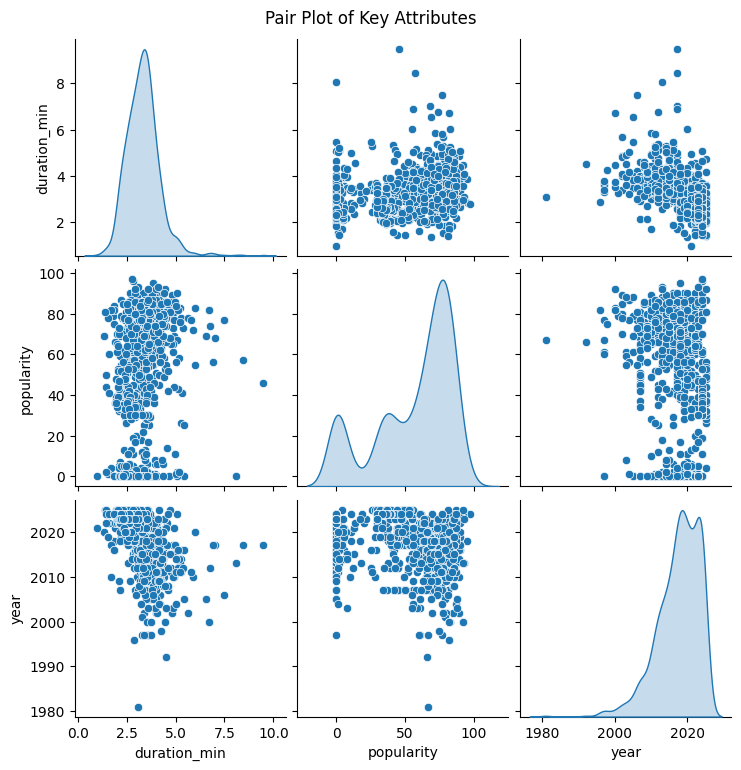

In [46]:
# Code Snippet 15
sns.pairplot(df[['duration_min', 'popularity', 'year']], diag_kind='kde')
plt.suptitle("Pair Plot of Key Attributes", y=1.02)
plt.show()


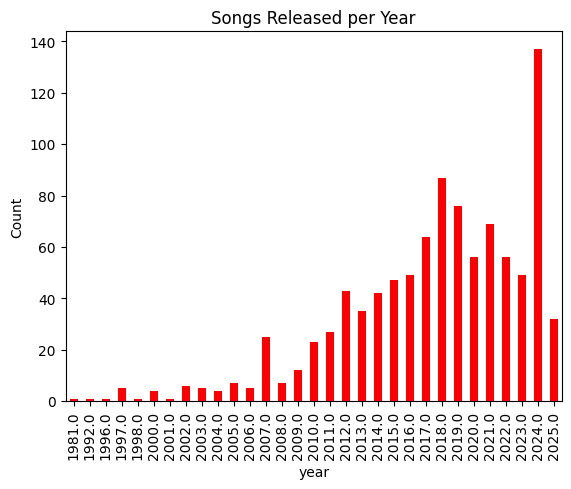

In [48]:
# Code Snippet 16
df['year'].value_counts().sort_index().plot(kind='bar', color='red')
plt.title("Songs Released per Year")
plt.ylabel('Count')
plt.show()


C:\Users\Jhonren\AppData\Local\Temp\ipykernel_24320\1793722391.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')


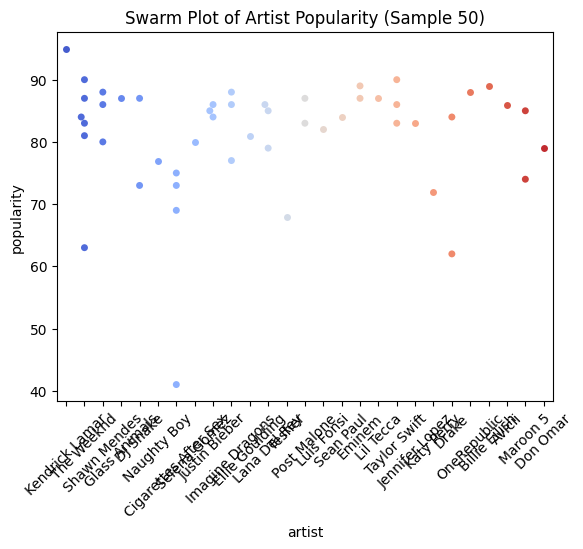

In [56]:
# Code Snippet 17
sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')
plt.title("Swarm Plot of Artist Popularity (Sample 50)")
plt.xticks(rotation=45)
plt.show()


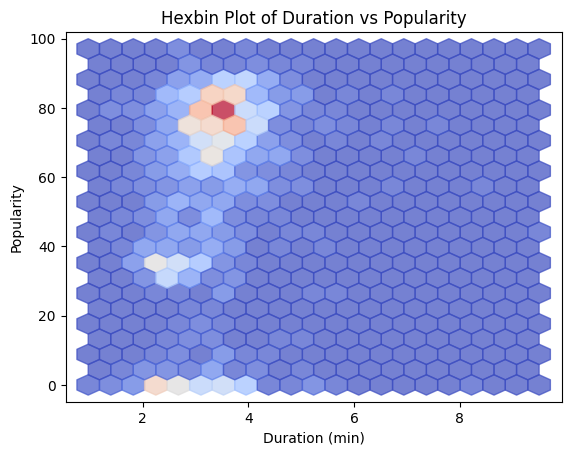

In [57]:
# Code Snippet 18
plt.hexbin(df['duration_min'], df['popularity'], gridsize=20, cmap='coolwarm', alpha=0.7)
plt.xlabel('Duration (min)')
plt.ylabel('Popularity')
plt.title("Hexbin Plot of Duration vs Popularity")
plt.show()


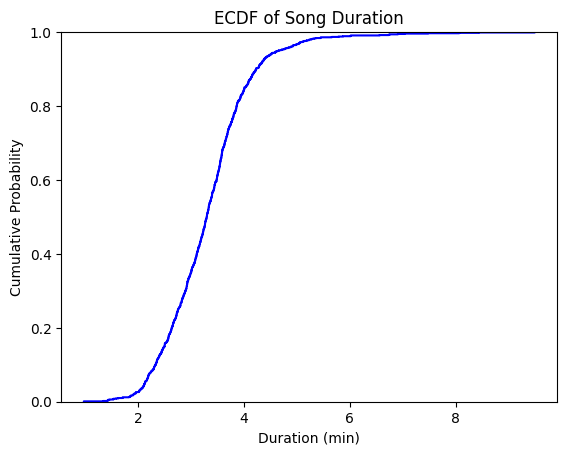

In [58]:
# Code Snippet 19
sns.ecdfplot(data=df, x='duration_min', color='blue')
plt.title("ECDF of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Cumulative Probability')
plt.show()


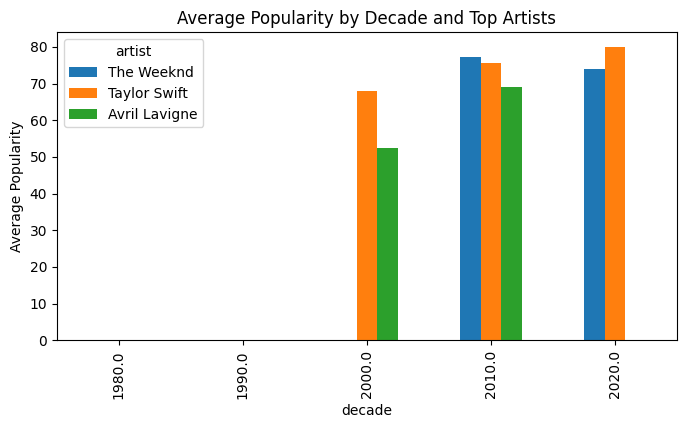

In [59]:
# Code Snippet 20
avg_artist_decade = df.groupby(['decade', 'artist'])['popularity'].mean().unstack().fillna(0)
top3 = df['artist'].value_counts().head(3).index
avg_artist_decade[top3].plot(kind='bar', figsize=(8, 4))
plt.title("Average Popularity by Decade and Top Artists")
plt.ylabel('Average Popularity')
plt.show()
